## SCP/SCA

In [35]:
import cvxpy as cp
import numpy as np

# ============================================================
# Constant settings
# ============================================================
N = 30                  # number of time steps
h = 0.1                 # time step
m = 1.0                 # mass
g = 10                # gravity
I = 0.1                # moment of inertia
r = 0.2                 # arm length / torque coefficient
u_max = 10.0            # max thrust per rotor
max_iters = 200          # SCP iterations
tol = 1e-3              # convergence tolerance

delta_x = 1   # trust region size for state
delta_u = 1.5   # trust region size for control

# State: x = [q1, v1, q2, v2, q3, w]
x0 = np.array([0.25, 0.0, 0.5, 0.0, 0.0, 0.0])
xT = np.array([0.75, 0.0, 1.5, 0.0, 0.0, 0.0])

# ============================================================
# Initial guess
# ============================================================
x_bar = np.zeros((6, N + 1))
u1_bar = 0.6 * u_max * np.ones(N)
u2_bar = 0.6 * u_max * np.ones(N)

x_bar[:, 0] = x0
for k in range(N):
    # simple straight-line initial guess for positions
    alpha = (k + 1) / N
    x_bar[0, k + 1] = (1 - alpha) * x0[0] + alpha * xT[0]
    x_bar[2, k + 1] = (1 - alpha) * x0[2] + alpha * xT[2]
    x_bar[4, k + 1] = (1 - alpha) * x0[4] + alpha * xT[4]
    x_bar[1, k + 1] = (x_bar[0, k + 1] - x_bar[0, k ])/h
    x_bar[3, k + 1] = (x_bar[2, k + 1] - x_bar[2, k ])/h
    x_bar[5, k + 1] = (x_bar[4, k + 1] - x_bar[4, k ])/h

# ============================================================
# SCP loop
# ============================================================
count = 0; #min_cost = np.inf
cost_list = []
for it in range(max_iters):
    # Decision variables
    x = cp.Variable((6, N + 1))
    u1 = cp.Variable(N)
    u2 = cp.Variable(N)

    constraints = []

    # Boundary conditions
    constraints += [x[:, 0] == x0]
    constraints += [x[:, N] == xT]

    # Dynamics linearization constraints
    for k in range(N):
        # Nominal values
        q1b = x_bar[0, k]
        v1b = x_bar[1, k]
        q2b = x_bar[2, k]
        v2b = x_bar[3, k]
        q3b = x_bar[4, k]
        wb  = x_bar[5, k]
        u1b = u1_bar[k]
        u2b = u2_bar[k]

        ub_sum = u1b + u2b
        db = u2b - u1b

        # Current variables
        q1 = x[0, k]
        v1 = x[1, k]
        q2 = x[2, k]
        v2 = x[3, k]
        q3 = x[4, k]
        w  = x[5, k]

        du1 = u1[k] - u1b
        du2 = u2[k] - u2b
        du_sum = du1 + du2
        dq3 = q3 - q3b

        # Linearize the nonlinear terms:
        # sin(q3)*(u1+u2) ≈ sin(q3b)*ub_sum + cos(q3b)*ub_sum*(q3-q3b) + sin(q3b)*( (u1-u1b)+(u2-u2b) )
        sinb = np.sin(q3b)
        cosb = np.cos(q3b)

        sin_term = sinb * ub_sum + cosb * ub_sum * dq3 + sinb * du_sum

        # cos(q3)*(u1+u2) ≈ cos(q3b)*ub_sum - sin(q3b)*ub_sum*(q3-q3b) + cos(q3b)*( (u1-u1b)+(u2-u2b) )
        cos_term = cosb * ub_sum - sinb * ub_sum * dq3 + cosb * du_sum

        # Explicit Euler discretization
        q1_next = q1 + h * v1
        v1_next = v1 + h * (-1.0 / m) * sin_term

        q2_next = q2 + h * v2
        v2_next = v2 + h * ((1.0 / m) * (cos_term - m * g))

        q3_next = q3 + h * w
        w_next  = w + h * (r / I) * (u2[k] - u1[k])

        constraints += [
            x[0, k + 1] == q1_next,
            x[1, k + 1] == v1_next,
            x[2, k + 1] == q2_next,
            x[3, k + 1] == v2_next,
            x[4, k + 1] == q3_next,
            x[5, k + 1] == w_next,
        ]

        constraints += [
        x[:, k] >= x_bar[:, k] - delta_x,
        x[:, k] <= x_bar[:, k] + delta_x,
        ]

        constraints += [
        u1[k] >= u1_bar[k] - delta_u,
        u1[k] <= u1_bar[k] + delta_u,
        u2[k] >= u2_bar[k] - delta_u,
        u2[k] <= u2_bar[k] + delta_u,
        ]   

    constraints += [
        x[:, N] >= x_bar[:, N] - delta_x,
        x[:, N] <= x_bar[:, N] + delta_x,
    ]

    # Control bounds
    constraints += [u1 >= 0, u1 <= u_max]
    constraints += [u2 >= 0, u2 <= u_max]

    # Objective: minimum effort
    objective = cp.Minimize(cp.sum_squares(u1) + cp.sum_squares(u2))

    # Solve convex subproblem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP, verbose=False)

    if it == 0:
        min_cost = problem.value

    print(f"Iteration {it+1}: status = {problem.status}, cost = {problem.value}, min cost={min_cost}")

    if problem.status not in ["optimal", "optimal_inaccurate"]:
        print("Solver failed.")
        break
    # Check convergence
    x_new = x.value
    u1_new = u1.value
    u2_new = u2.value

    dx = np.max(np.abs(x_new - x_bar))
    du = max(np.max(np.abs(u1_new - u1_bar)), np.max(np.abs(u2_new - u2_bar)))

    x_bar = x_new.copy()
    u1_bar = u1_new.copy()
    u2_bar = u2_new.copy()

    current_cost = problem.value
    cost_list.append(current_cost)
    if current_cost < min_cost:
        if min_cost - current_cost > 0.01:
            min_cost = current_cost
            count = 0
        else:
            count = count + 1
    else: 
        count = count + 1
    if count >= 20:
        print("Cost Converge")
        break
    
    #if max(dx, du) < tol:
    #    print("Converged.")
    #    break
    

# ============================================================
# Results
# ============================================================
print("\nFinal solution:")
print("x =", x_bar)
print("u1 =", u1_bar)
print("u2 =", u2_bar)

Iteration 1: status = optimal, cost = 1502.3262912256077, min cost=1502.3262912256077
Iteration 2: status = optimal, cost = 1503.290403418676, min cost=1502.3262912256077
Iteration 3: status = optimal, cost = 1503.288968673188, min cost=1502.3262912256077
Iteration 4: status = optimal, cost = 1503.236444524931, min cost=1502.3262912256077
Iteration 5: status = optimal, cost = 1503.016292626192, min cost=1502.3262912256077
Iteration 6: status = optimal, cost = 1501.677603008508, min cost=1502.3262912256077
Iteration 7: status = optimal, cost = 1492.7524818736356, min cost=1501.677603008508
Iteration 8: status = optimal, cost = 1470.437251439329, min cost=1492.7524818736356
Iteration 9: status = optimal, cost = 1489.3636939803127, min cost=1470.437251439329
Iteration 10: status = optimal, cost = 1469.7070197595551, min cost=1470.437251439329
Iteration 11: status = optimal, cost = 1489.1903674908174, min cost=1469.7070197595551
Iteration 12: status = optimal, cost = 1469.708011105903, min

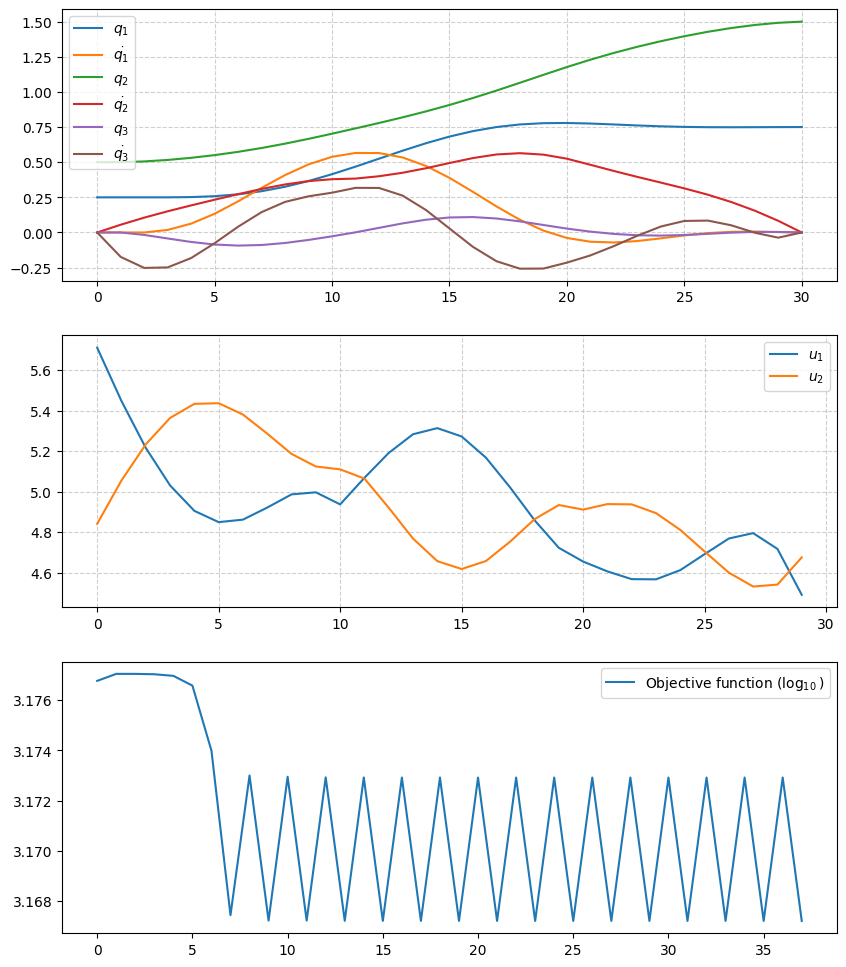

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=3, figsize=(10,12))

axes[0].grid(True, linestyle='--', alpha=0.6)

axes[0].plot(x_bar[0], label=r"$q_1$")
axes[0].plot(x_bar[1], label=r"$\dot{q_1}$")
axes[0].plot(x_bar[2], label=r"$q_2$")
axes[0].plot(x_bar[3], label=r"$\dot{q_2}$")
axes[0].plot(x_bar[4], label=r"$q_3$")
axes[0].plot(x_bar[5], label=r"$\dot{q_3}$")
axes[0].legend()

axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].plot(u1_bar, label=r"$u_1$")
axes[1].plot(u2_bar, label=r"$u_2$")
axes[1].legend()

axes[2].plot(np.log10(cost_list), label=r"Objective function ($\log_{10}$)")
axes[2].legend()

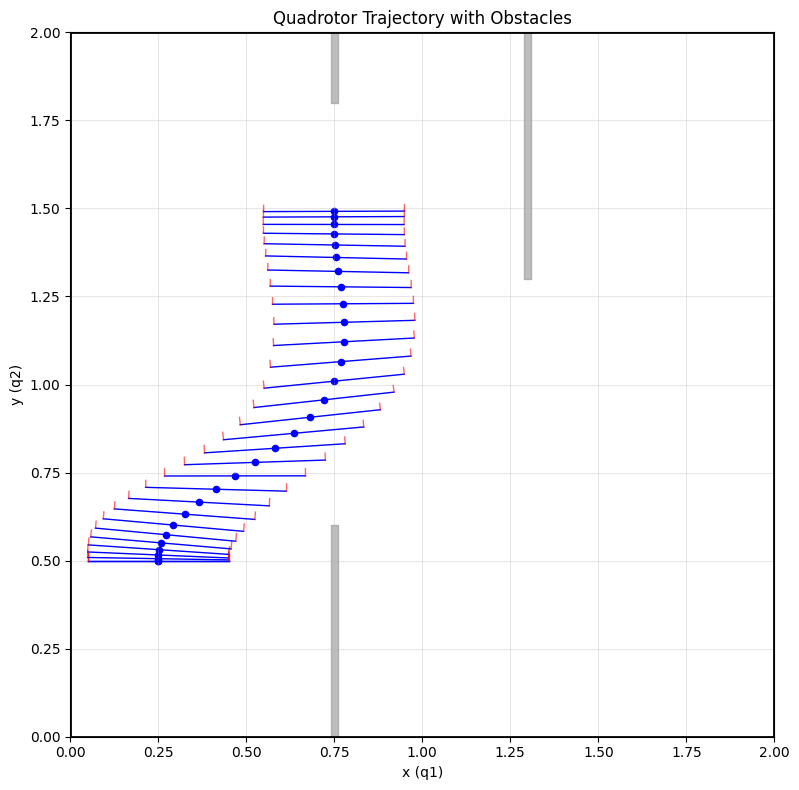

In [37]:
from plot_utils import *
import numpy as np

q_traj = np.array([x_bar[0, :], x_bar[2, :],x_bar[4, :]]).T
u_traj = np.array([u1_bar, u2_bar]).T
plot_trajectory(2, 2, {'r': .2}, 
    [{'x': .75, 'uh': .2, 'bh': .6}, 
    {'x': 1.3, 'uh': 0.7, 'bh': 0}], 
    q_traj, 
    u_traj)

## Alternative SCA (Not Work)

In [34]:
"""import cvxpy as cp
import numpy as np

# ============================================================
# Constant settings
# ============================================================
N = 60                  # number of time steps
h = 0.1                 # time step
m = 1.0                 # mass
g = 10                # gravity
I = 0.1                # moment of inertia
r = 0.2                 # arm length / torque coefficient
u_max = 10.0            # max thrust per rotor
max_iters = 100         # alternating optimization iterations
tol = 1e-3              # convergence tolerance

delta_x = 1   # trust region size for state
delta_u = 1.2   # trust region size for control

# State: x = [q1, v1, q2, v2, q3, w]
x0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
xT = np.array([1.0, 0.0, 1.0, 0.0, 0.0, 0.0])

# ============================================================
# Initial guess
# ============================================================
x_bar = np.zeros((6, N + 1))
u1_bar = 0.4 * u_max * np.ones(N)
u2_bar = 0.4 * u_max * np.ones(N)

x_bar[:, 0] = x0
for k in range(N):
    # simple straight-line initial guess for positions
    alpha = (k + 1) / N
    x_bar[0, k + 1] = (1 - alpha) * x0[0] + alpha * xT[0]
    x_bar[2, k + 1] = (1 - alpha) * x0[2] + alpha * xT[2]
    x_bar[4, k + 1] = (1 - alpha) * x0[4] + alpha * xT[4]
    x_bar[1, k + 1] = (x_bar[0, k + 1] - x_bar[0, k]) / h
    x_bar[3, k + 1] = (x_bar[2, k + 1] - x_bar[2, k]) / h
    x_bar[5, k + 1] = (x_bar[4, k + 1] - x_bar[4, k]) / h

# ============================================================
# Alternating Optimization Loop
# ============================================================
for it in range(max_iters):
    # ========================================================
    # U-STEP: Optimize control u with state x_bar fixed
    # (Dynamics constraints become linear in u)
    # ========================================================
    u1 = cp.Variable(N)
    u2 = cp.Variable(N)

    u_constraints = []

    # Dynamics constraints with x_bar fixed (linear in u)
    for k in range(N):
        v1 = x_bar[1, k]
        v2 = x_bar[3, k]
        q3 = x_bar[4, k]
        w = x_bar[5, k]

        v1_next = x_bar[1, k + 1]
        v2_next = x_bar[3, k + 1]
        q3_next = x_bar[4, k + 1]
        w_next = x_bar[5, k + 1]

        sinq3 = np.sin(q3)
        cosq3 = np.cos(q3)

        # Linearized dynamics (with x fixed, sin/cos are constants):
        # v1_next = v1 + h * (1/m) * sin(q3) * (u1 + u2)
        # v2_next = v2 + h * ((1/m) * cos(q3) * (u1 + u2) - g)
        # q3_next = q3 + h * w  (always satisfied)
        # w_next = w + h * (r/I) * (u2 - u1)

        u_constraints += [
            v1_next == v1 + (h / m) * (sinq3 * (u1[k] + u2[k])),
            v2_next == v2 + (h / m) * cosq3 * (u1[k] + u2[k]) - h * g,
            w_next == w + (h * r / I) * (u2[k] - u1[k]),
        ]

    # Control bounds
    u_constraints += [u1 >= 0, u1 <= u_max]
    u_constraints += [u2 >= 0, u2 <= u_max]

    # Trust region
    u_constraints += [
        u1 >= u1_bar - delta_u,
        u1 <= u1_bar + delta_u,
        u2 >= u2_bar - delta_u,
        u2 <= u2_bar + delta_u,
    ]

    # Objective: minimize control effort
    u_objective = cp.Minimize(cp.sum_squares(u1) + cp.sum_squares(u2))

    u_problem = cp.Problem(u_objective, u_constraints)
    u_problem.solve(solver=cp.OSQP, verbose=False)

    if u_problem.status not in ["optimal", "optimal_inaccurate"]:
        print(f"U-step iteration {it+1}: solver failed (status={u_problem.status})")
        u1_new = u1_bar.copy()
        u2_new = u2_bar.copy()
    else:
        u1_new = u1.value.copy()
        u2_new = u2.value.copy()

    # ========================================================
    # X-STEP: Optimize state x with control u fixed to u_new
    # ========================================================
    x = cp.Variable((6, N + 1))

    x_constraints = []

    # Boundary conditions
    x_constraints += [x[:, 0] == x0]
    x_constraints += [x[:, N] == xT]

    # Linearized dynamics constraints with u_bar = u_new fixed
    for k in range(N):
        # Nominal state (current estimate)
        q1b = x_bar[0, k]
        v1b = x_bar[1, k]
        q2b = x_bar[2, k]
        v2b = x_bar[3, k]
        q3b = x_bar[4, k]
        wb = x_bar[5, k]

        # Nominal controls (fixed to u_new)
        u1b = u1_new[k]
        u2b = u2_new[k]

        ub_sum = u1b + u2b
        db = u2b - u1b

        # Current variables
        q1 = x[0, k]
        v1 = x[1, k]
        q2 = x[2, k]
        v2 = x[3, k]
        q3 = x[4, k]
        w = x[5, k]

        dq3 = q3 - q3b

        # Linearize nonlinear terms around (q3b, u_sum_b)
        sinb = np.sin(q3b)
        cosb = np.cos(q3b)

        # sin(q3) * (u1 + u2) ≈ sin(q3b) * ub_sum + cos(q3b) * ub_sum * (q3 - q3b)
        sin_term = sinb * ub_sum + cosb * ub_sum * dq3

        # cos(q3) * (u1 + u2) ≈ cos(q3b) * ub_sum - sin(q3b) * ub_sum * (q3 - q3b)
        cos_term = cosb * ub_sum - sinb * ub_sum * dq3

        # Explicit Euler discretization
        q1_next = q1 + h * v1
        v1_next = v1 + h * (1.0 / m) * -sin_term

        q2_next = q2 + h * v2
        v2_next = v2 + h * ((1.0 / m) * (cos_term - m * g))

        q3_next = q3 + h * w
        w_next = w + h * (r / I) * db

        x_constraints += [
            x[0, k + 1] == q1_next,
            x[1, k + 1] == v1_next,
            x[2, k + 1] == q2_next,
            x[3, k + 1] == v2_next,
            x[4, k + 1] == q3_next,
            x[5, k + 1] == w_next,
        ]

        # Trust region
        x_constraints += [
            x[:, k] >= x_bar[:, k] - delta_x,
            x[:, k] <= x_bar[:, k] + delta_x,
        ]

    x_constraints += [
        x[:, N] >= x_bar[:, N] - delta_x,
        x[:, N] <= x_bar[:, N] + delta_x,
    ]

    # Objective: minimize control effort (constant w.r.t. x, but include for completeness)
    x_objective = cp.Minimize(cp.sum_squares(u1_new) + cp.sum_squares(u2_new))

    x_problem = cp.Problem(x_objective, x_constraints)
    x_problem.solve(solver=cp.OSQP, verbose=False)

    if x_problem.status not in ["optimal", "optimal_inaccurate"]:
        print(f"X-step iteration {it+1}: solver failed (status={x_problem.status})")
        x_new = x_bar.copy()
    else:
        x_new = x.value.copy()

    # ========================================================
    # Convergence check and update
    # ========================================================
    dx = np.max(np.abs(x_new - x_bar))
    du1 = np.max(np.abs(u1_new - u1_bar))
    du2 = np.max(np.abs(u2_new - u2_bar))
    du = max(du1, du2)

    cost = np.sum(u1_new**2) + np.sum(u2_new**2)
    print(f"Iteration {it+1}: cost = {cost:.6f}, dx = {dx:.6e}, du = {du:.6e}")

    x_bar = x_new.copy()
    u1_bar = u1_new.copy()
    u2_bar = u2_new.copy()

    if max(dx, du) < tol:
        print("Converged.")
        break

# ============================================================
# Results
# ============================================================
print("\nFinal solution:")
print("x shape:", x_bar.shape)
print("u1 shape:", u1_bar.shape)
print("u2 shape:", u2_bar.shape)
print("\nFinal cost:", np.sum(u1_bar**2) + np.sum(u2_bar**2))
print("\nFirst few steps of u1:", u1_bar[:5])
print("First few steps of u2:", u2_bar[:5])
"""

'import cvxpy as cp\nimport numpy as np\n\n# ============================================================\n# Constant settings\n# ============================================================\nN = 60                  # number of time steps\nh = 0.1                 # time step\nm = 1.0                 # mass\ng = 10                # gravity\nI = 0.1                # moment of inertia\nr = 0.2                 # arm length / torque coefficient\nu_max = 10.0            # max thrust per rotor\nmax_iters = 100         # alternating optimization iterations\ntol = 1e-3              # convergence tolerance\n\ndelta_x = 1   # trust region size for state\ndelta_u = 1.2   # trust region size for control\n\n# State: x = [q1, v1, q2, v2, q3, w]\nx0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])\nxT = np.array([1.0, 0.0, 1.0, 0.0, 0.0, 0.0])\n\n# ============================================================\n# Initial guess\n# ============================================================\nx_bar = np.zeros((